# Transition design examples

Taper/transition designs between waveguide widths (and, in the dual-layer case, between
two process layers), evaluated with a Lumerical MODE EME simulation.

## Step 0: Open the Lumerical MODE session

In [26]:
%load_ext autoreload
%autoreload 2

from functools import partial

import lumapi
import numpy as np
import matplotlib.pyplot as plt

import lumapi_util as lu
from lumapi_util.paths import STACK_DATA_DIR

sim = lumapi.MODE()
backend = lu.LumericalModeBackend(sim)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Shared geometry and sweep helpers

`build_transition` builds a taper geometry from a list of per-layer specs (one entry for a
single-layer transition, two entries for a dual-layer transition) and sets up the EME
simulation. `taper_length_sweep` sweeps the taper length of a given EME cell group and reports
the excess loss.

- **Layer specs**: each entry in `layers` describes one tapered layer (`layer` name, initial/final
  width `wi`/`wf`, `length`, optional `x0`/`y0` offset, optional straight `extension`, and an
  optional `profile` — see the profile-comparison section below for the available shapes,
  including how to pass a custom one).
- **EME cells**: the taper is split into `[input straight, layer offset, shortest taper, length
  mismatch, output straight]` cells so multi-layer tapers of different lengths line up; zero-length
  cells are dropped.
- **Monitors**: two `configure_eme_profile` calls set up XY and XZ field-profile monitors so the
  mode can be inspected in both cross-sections after propagation.
- `compute_excess_loss` converts the EME propagation scattering matrix to dB and reports the
  loss of the fundamental transmitted mode.
- `taper_length_sweep` wraps `lu.sweep_param_result` to re-run `set_eme_group_lengths` +
  `compute_excess_loss` over a range of lengths, returning both the raw excess-loss array and
  the sweep summary (and optionally plotting the result).

In [2]:

# Defaults for build_transition; override any of these by passing them as keyword arguments
default_transition_params = {
    "wavelength": 1.55,
    "sim_size": (3, 3),
    "n_modes": 10,
    "mesh_steps": (0.02, 0.02),
    "bc": ["Anti-Symmetric", "PML", "PML", "PML"],
    "eme_offset": 1.0,
    "profile_size": (60, 20),
}


def build_transition(backend, layers, **params):
    """Set up an EME taper/transition from one or more per-layer geometry specs."""
    params = {**default_transition_params, **params}

    backend.switch_to_layout()
    backend.clear_layer_geometries()

    lengths = [layer["length"] for layer in layers]
    x_offsets = [layer.get("x0", 0.0) for layer in layers]
    widths = []
    layer_infos = []

    for layer in layers:
        wi, wf, length = layer["wi"], layer["wf"], layer["length"]
        extension = layer.get("extension", (0.0, 0.0))
        profile = layer.get("profile", "linear")
        offset = np.array([layer.get("x0", 0.0), layer.get("y0", 0.0)])

        backend.configure_layer(layer["layer"], sidewall_angle=layer.get("sidewall_angle", 90))
        taper = lu.build_profile_taper(wi, wf, length, extension=extension, profile=profile) + offset
        backend.set_layer_geometries(layer["layer"], [taper])

        widths.extend([wi, wf])
        layer_infos.append(backend.get_layer_info(layer["layer"]))

    # Cells: [entrance straight, offset to a later-starting layer, shared taper, extra length
    # of the longer layer, exit straight]; drop any zero-length cell (e.g. no offset).
    offset = max(x_offsets, default=0.0)
    shortest_length, longest_length = min(lengths), max(lengths)
    cell_lengths = [1.0, offset, shortest_length, longest_length - shortest_length, 1.0]
    eme_cells = [(int(length), length) for length in cell_lengths if length > 0]

    sim_width, sim_height = params["sim_size"]
    z0, thickness = layer_infos[0]["z0"], layer_infos[0]["t"]
    zc = z0 + thickness / 2  # vertical center of the first layer, used to center the EME/mesh/monitors
    eme_offset = params["eme_offset"]

    backend.configure_eme(
        size=[None, sim_width, sim_height],
        center=[eme_offset, 0.0, zc],
        cells=eme_cells,
        bc=params["bc"],
        wavelength=params["wavelength"],
        n_modes=params["n_modes"],
    )
    backend.configure_mesh(
        name="mesh_struct",
        size=[sum(cell_lengths) + 2, max(widths), thickness],
        center=[sum(cell_lengths) / 2 + eme_offset, 0.0, zc],
        steps=[None, *params["mesh_steps"]],
    )

    profile_x, profile_span = params["profile_size"]
    # Top-down (XY) field profile monitor
    backend.configure_eme_profile(size=[profile_x, profile_span, None], center=[profile_x / 2, 0.0, zc])
    # Side (XZ) field profile monitor
    backend.configure_eme_profile(size=[profile_x, None, profile_span / 2], center=[profile_x / 2, 0.0, zc])


def compute_excess_loss(backend):
    scattering_matrix = backend.eme_propagation()
    power = 2 * lu.lin2db(scattering_matrix)
    return -power[1, 0]


def set_eme_group_lengths(backend, cell_range, length):
    return lu.set_eme_group_lengths(backend.sim, cell_range, length)


def taper_length_sweep(backend, cell_range=1, lengths=None, plot=True, filename="taper_length_sweep.csv"):
    if lengths is None:
        lengths = np.arange(1, 30, 1)

    excess_loss, summary = lu.sweep_param_result(
        backend,
        sweep_params={"length": lengths},
        geometry_params={"cell_range": cell_range},
        geometry_fn=set_eme_group_lengths,
        result_fn=compute_excess_loss,
        result_type=float,
        save_path=filename,
    )

    if plot:
        lu.plot_metric_1d({"length": lengths}, excess_loss, x_param="length", metric_name="Excess Loss")

    return excess_loss, summary


## Taper width profiles

`build_profile_taper` (and the `profile` key on a layer spec) accepts either the name of a
built-in shape or an arbitrary callable:

- `"linear"` — constant-curvature (degree-1) width change.
- `"parabolic"` — degree-2 width change, flatter near the wide end.
- `"sine"` — smooth sinusoidal blend between `wi` and `wf`.
- `"exponential"` — exponential blend, concentrating the width change near one end.
- a **custom callable** `fn(wi, wf, length, n_points=...) -> Nx2 array of (x, width)` — passed
  through unchanged by `lu.get_profile`, so any shape not in the built-in set can be used without
  modifying the library.

The next cell plots just the width-vs-position curves (no simulation) so the shapes can be
compared directly, followed by a definition of a custom profile and a full excess-loss sweep
that overlays all of them for the Si transition from Example 1.

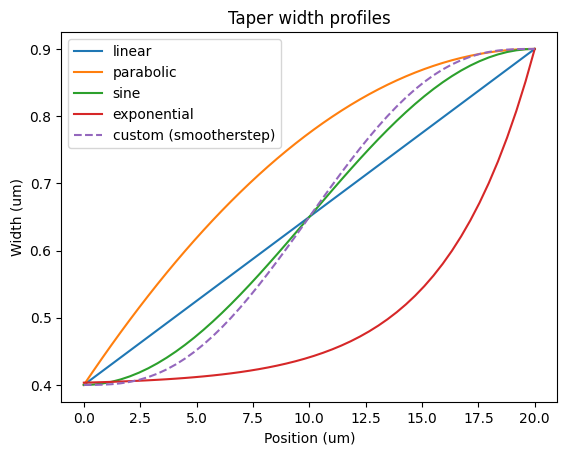

In [4]:
def smootherstep_profile(wi, wf, length, n_points=50):
    """Custom shape: 5th-order smootherstep, zero curvature at both ends unlike the built-ins."""
    x = np.linspace(0, 1, n_points)
    blend = 6 * x**5 - 15 * x**4 + 10 * x**3
    y = wi + (wf - wi) * blend
    return np.column_stack((x * length, y))


builtin_profiles = ["linear", "parabolic", "sine", "exponential"]
demo_wi, demo_wf, demo_length = 0.4, 0.9, 20

plt.figure()
for name in builtin_profiles:
    profile = lu.get_profile(name)(demo_wi, demo_wf, demo_length)
    plt.plot(profile[:, 0], profile[:, 1], label=name)
custom_profile = smootherstep_profile(demo_wi, demo_wf, demo_length)
plt.plot(custom_profile[:, 0], custom_profile[:, 1], "--", label="custom (smootherstep)")
plt.xlabel("Position (um)")
plt.ylabel("Width (um)")
plt.title("Taper width profiles")
plt.legend()
plt.show()


## Example 1: single-layer transition in Si at 1550 nm

Taper a single silicon waveguide layer from a narrow to a wider width, using the generic
sample SOI stack.

In [5]:
backend.clear_geometry()

stack_file = STACK_DATA_DIR / "sample_soi.lbr"
stack_length = 100
backend.load_layer_stack(stack_file, size=[stack_length, 20, None])

si_transition = [
    {"layer": "WG", "wi": 0.4, "wf": 0.9, "length": 20, "extension": (2, 2)},
]

si_transition_setup = partial(build_transition, layers=si_transition, wavelength=1.55)
si_transition_setup(backend)

[ensure_object] 'EME' not found. Creating a new 'EME'...
[ensure_object] 'mesh_struct' not found. Creating a new 'mesh'...
[ensure_object] 'profile z-normal' not found. Creating a new 'emeprofile'...
[ensure_object] 'profile y-normal' not found. Creating a new 'emeprofile'...


In [6]:
backend.run_eme("si_transition_1550nm.lms")

100%|██████████| 49/49 [00:08<00:00,  5.64it/s, parameters=length=49]

✅ Sweep completed. Results saved to: si_transition_1550nm_sweep.csv


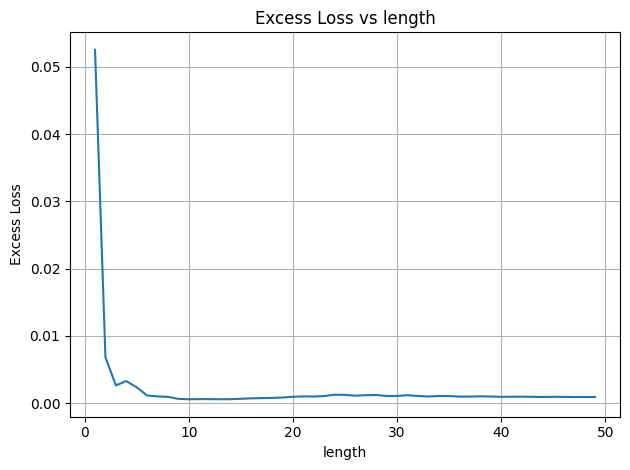

In [7]:
# cell_range = backend.expand_eme_cell_group(3)
lengths = np.arange(1, 50, 1)
excess_loss, summary = taper_length_sweep(backend, cell_range=1, lengths=lengths, filename="si_transition_1550nm_sweep.csv")


### Comparing profiles on the same geometry

Re-run the excess-loss-vs-length sweep above for each width profile (the four built-ins plus
the `smootherstep_profile` custom callable defined earlier) on the same Si geometry, then
overlay all the curves on a single plot.

In [8]:
profiles_to_compare = {**{name: name for name in builtin_profiles}, "custom (smootherstep)": smootherstep_profile}
excess_loss_by_profile = {}

for name, profile in profiles_to_compare.items():
    si_transition[0]["profile"] = profile
    si_transition_setup(backend)
    tag = name.split(" ")[0]
    backend.run_eme(f"si_transition_1550nm_{tag}.lms")
    excess_loss, _ = taper_length_sweep(
        backend, cell_range=1, lengths=lengths, plot=False, filename=f"si_transition_1550nm_{tag}_sweep.csv"
    )
    excess_loss_by_profile[name] = excess_loss


100%|██████████| 49/49 [00:07<00:00,  6.27it/s, parameters=length=49]


✅ Sweep completed. Results saved to: si_transition_1550nm_linear_sweep.csv


100%|██████████| 49/49 [02:18<00:00,  2.83s/it, parameters=length=49]


✅ Sweep completed. Results saved to: si_transition_1550nm_parabolic_sweep.csv


100%|██████████| 49/49 [00:17<00:00,  2.78it/s, parameters=length=49]


✅ Sweep completed. Results saved to: si_transition_1550nm_sine_sweep.csv


100%|██████████| 49/49 [00:09<00:00,  4.96it/s, parameters=length=49]


✅ Sweep completed. Results saved to: si_transition_1550nm_exponential_sweep.csv


100%|██████████| 49/49 [00:09<00:00,  4.90it/s, parameters=length=49]

✅ Sweep completed. Results saved to: si_transition_1550nm_custom_sweep.csv


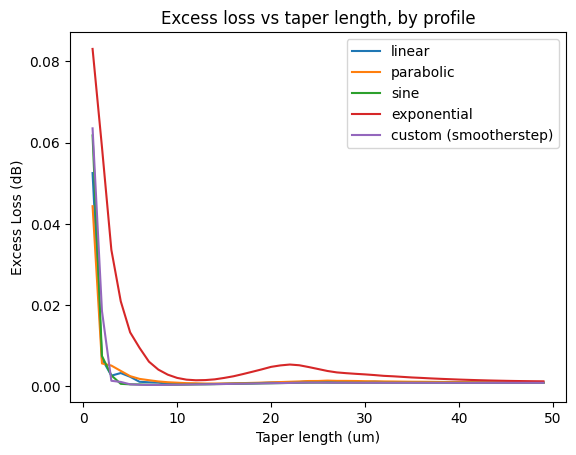

In [9]:
plt.figure()
for name, excess_loss in excess_loss_by_profile.items():
    plt.plot(lengths, excess_loss, label=name)
plt.xlabel("Taper length (um)")
plt.ylabel("Excess Loss (dB)")
plt.title("Excess loss vs taper length, by profile")
plt.legend()
plt.show()

### Reading the combined plot

The ripple is expected from coupled-mode theory (Marcuse, *Theory of Dielectric Optical
Waveguides*, 1991; Milton & Burns, *IEEE J. Quantum Electron.* **QE-13**, 828, 1977), not a
simulation artifact. To first order, the power coupled from the fundamental mode into a
higher-order mode over a taper of length $L$ is

$$P_{12}(L) = \left|\int_0^L \kappa_{12}(z)\, e^{i\Delta\beta z}\,dz\right|^2 ,\qquad
\kappa_{12}(z)\propto \frac{dW}{dz},\quad \Delta\beta=\beta_1-\beta_2 = \frac{2\pi}{\lambda_0}\Delta n_{\rm eff}.$$

Stretching $L$ modulates this Fourier-type integral, so $P_{12}$ (and thus the excess loss)
oscillates with a spatial period equal to the modal beat length $L_{\rm beat}=2\pi/\Delta\beta
=\lambda_0/\Delta n_{\rm eff}$, on top of an envelope that shrinks as the taper becomes more
adiabatic — exactly the dip/rise/settle shape seen here for every profile.

The oscillation amplitude is set by how large $\kappa_{12}(z)\propto dW/dz$ gets, in particular
near the taper's boundaries (Milton–Burns adiabaticity criterion: local taper angle $\lesssim
\lambda_0/2W\Delta n_{\rm eff}$). `sine` and `smootherstep` have $dW/dz=0$ at both ends, `linear`
has a constant, discontinuous $dW/dz$, `parabolic` vanishes at only one end, and the front-loaded
`exponential` has the largest $dW/dz$ of all — matching the measured minima (≈0.39, 0.59, 0.71,
0.37, 1.5 ×10⁻³ dB for sine/linear/parabolic/custom/exponential) and beat amplitudes.

**Best here:** `smootherstep` (custom), closely followed by `sine` — lowest minimum loss and
smallest ripple, as predicted by their vanishing endpoint derivatives. `exponential` is worst.

## Fast profile synthesis via cell-group span reassignment

The comparison above re-solves the per-slice eigenmodes from scratch for every
profile, which is why it took several minutes. There is a much faster way to explore
(or eventually optimize) width profiles: solve the expensive per-slice eigenmodes
**once**, on a single linear reference taper, then reuse those solved slices for every
other candidate profile by only reassigning how much z-length each slice gets —
`x(w) = f⁻¹(w)` instead of `w(x) = f(x)`.

- Build one **linear** reference taper with N discrete width steps. Each junction's
  mode-conversion strength depends only on the local Δwidth between adjacent steps,
  so it only needs to be solved once, regardless of which target profile we want to
  emulate afterward.
- `backend.expand_eme_cell_group` must be called **before** the (single) `run_eme`
  solve, not after — expansion is a layout-mode structural edit, not a solve. Solving
  before expanding would compute modes for the wrong (pre-expansion) cell count and
  force a second, redundant solve. `expand_eme_cell_group` returns the `cell_range`
  slice, which is what lets `set_eme_group_lengths` set all N subcell lengths
  *simultaneously* afterward — the core mechanism this technique relies on.
- Lumerical's CVCS ("Continuously Varying Cross-sectional Subcell") method already
  smooths the staircase approximation of the *reference* linear taper before
  expansion (`eme_cell_properties` enables it automatically for any multi-subcell
  group). It does not apply after expansion, though: every expanded subcell has a
  single fixed width, so there is nothing left to interpolate — accuracy from that
  point on depends only on how many reference slices (N) were solved.
- For a target profile and length, redistributing z-length only changes the
  propagation *phase* accumulated across each already-solved slice; the junction
  coupling strengths (which set how much power leaks to the higher-order mode) are
  fixed by the reference's N equally-spaced widths. This is a forward-evaluation
  method only here — no optimization loop over `x(w)` yet.

In [21]:
backend.clear_geometry()

stack_file = STACK_DATA_DIR / "sample_soi.lbr"
stack_length = 100
backend.load_layer_stack(stack_file, size=[stack_length, 20, None])

si_ref_taper = [
    {"layer": "WG", "wi": 0.4, "wf": 0.9, "length": 20, "extension": (2, 2), "profile": "linear"},
]
si_ref_setup = partial(build_transition, layers=si_ref_taper, wavelength=1.55)
si_ref_setup(backend)  # leaves the session in layout mode - do not run_eme yet

cell_range = backend.expand_eme_cell_group(2)  # taper is EME cell group 2 (entrance, taper, exit)
backend.run_eme("si_transition_1550nm_cvcs_reference.lms")  # single solve for all N reference slices

[ensure_object] 'EME' not found. Creating a new 'EME'...
[ensure_object] 'mesh_struct' not found. Creating a new 'mesh'...
[ensure_object] 'profile z-normal' not found. Creating a new 'emeprofile'...
[ensure_object] 'profile y-normal' not found. Creating a new 'emeprofile'...


In [22]:
def lengths_for_profile(profile, wi, wf, length, n_slices, n_fine=2000):
    """Invert a target profile's z(w) at the reference's N equally-spaced widths."""
    z_fine, w_fine = lu.get_profile(profile)(wi, wf, length, n_points=n_fine).T
    w_edges = np.linspace(wi, wf, n_slices + 1)
    z_edges = np.interp(w_edges, w_fine, z_fine)
    return np.diff(z_edges)

In [23]:
import time

n_slices = cell_range.stop - cell_range.start
wi, wf = si_ref_taper[0]["wi"], si_ref_taper[0]["wf"]
fast_excess_loss_by_profile = {}

t0 = time.time()
for name, profile in profiles_to_compare.items():
    losses = []
    for length in lengths:
        subcell_lengths = lengths_for_profile(profile, wi, wf, length, n_slices)
        set_eme_group_lengths(backend, cell_range, subcell_lengths)
        losses.append(compute_excess_loss(backend))
    fast_excess_loss_by_profile[name] = np.array(losses)
fast_elapsed = time.time() - t0

print(f"Fast method: {fast_elapsed:.1f}s for {len(profiles_to_compare)} profiles x {len(lengths)} lengths, one solve total")

Fast method: 24.0s for 5 profiles x 49 lengths, one solve total


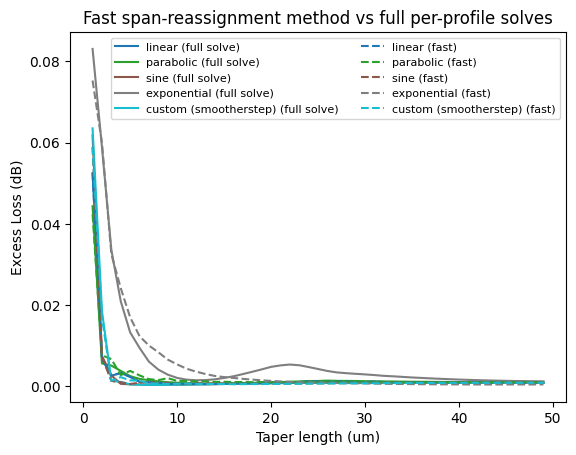

In [24]:
plt.figure()
colors = plt.cm.tab10(np.linspace(0, 1, len(profiles_to_compare)))
for color, (name, loss) in zip(colors, excess_loss_by_profile.items()):
    plt.plot(lengths, loss, color=color, label=f"{name} (full solve)")
for color, (name, loss) in zip(colors, fast_excess_loss_by_profile.items()):
    plt.plot(lengths, loss, "--", color=color, label=f"{name} (fast)")
plt.xlabel("Taper length (um)")
plt.ylabel("Excess Loss (dB)")
plt.title("Fast span-reassignment method vs full per-profile solves")
plt.legend(fontsize=8, ncol=2)
plt.show()

### Reading the fast-method comparison

The dashed ("fast") curves reuse a single reference solve for all five profiles and
every swept length, instead of one full solve per profile — compare the printed
elapsed time against the multi-minute duration of the "Comparing profiles" section
above for the actual speed-up. Agreement between solid and dashed curves validates
the approximation; any systematic mismatch (most likely for `exponential`, which has
the steepest local Δwidth) indicates the reference taper's N=20 slices are too coarse
to resolve that profile's junction coupling accurately, and would need a finer
reference (larger N) to match the full-solve result.

## Example 2: single-layer transition in SiN at 632 nm

Same `build_transition`/`taper_length_sweep` helpers as Example 1, reused for a different
process layer (SiN), stack file, and wavelength.

In [18]:
backend.clear_geometry()

stack_file = STACK_DATA_DIR / "sample_sin.lbr"
stack_length = 100
backend.load_layer_stack(stack_file, size=[stack_length, 20, None])

sin_transition = [
    {"layer": "WG", "wi": 0.3, "wf": 0.8, "length": 20, "extension": (2, 2)},
]

sin_transition_setup = partial(build_transition, layers=sin_transition, wavelength=0.632)
sin_transition_setup(backend)

[ensure_object] 'EME' not found. Creating a new 'EME'...
[ensure_object] 'mesh_struct' not found. Creating a new 'mesh'...
[ensure_object] 'profile z-normal' not found. Creating a new 'emeprofile'...
[ensure_object] 'profile y-normal' not found. Creating a new 'emeprofile'...


In [19]:
backend.run_eme("sin_transition_632nm.lms")

100%|██████████| 29/29 [00:05<00:00,  5.73it/s, parameters=length=29]


✅ Sweep completed. Results saved to: sin_transition_632nm_sweep.csv


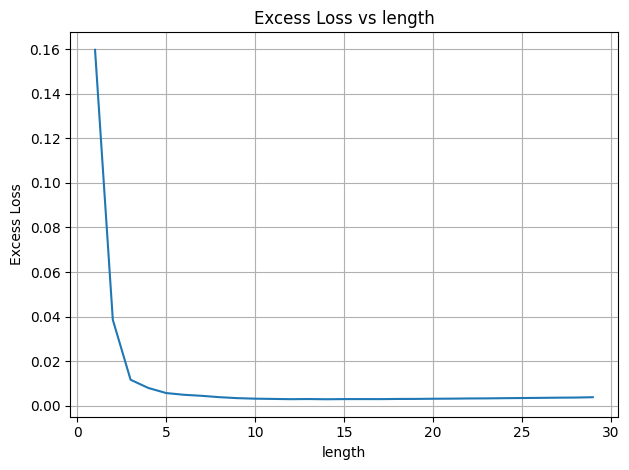

In [20]:
# cell_range=1 matches the taper cell for this single-layer geometry, same as Example 1
excess_loss, summary = taper_length_sweep(backend, cell_range=1, filename="sin_transition_632nm_sweep.csv")

### Scalability check: fast profile comparison on SiN at 632 nm

Apply the fast span-reassignment method (expand before solving, one solve, then reuse
`lengths_for_profile` per profile) to this SiN geometry — much lower index contrast
and less than half the wavelength of the Si 1550 nm case — as a first scalability
check, without re-running the full per-profile ground truth.

In [27]:
backend.clear_geometry()

stack_file = STACK_DATA_DIR / "sample_sin.lbr"
stack_length = 100
backend.load_layer_stack(stack_file, size=[stack_length, 20, None])

sin_ref_taper = [
    {"layer": "WG", "wi": 0.3, "wf": 0.8, "length": 20, "extension": (2, 2), "profile": "linear"},
]
sin_ref_setup = partial(build_transition, layers=sin_ref_taper, wavelength=0.632)
sin_ref_setup(backend)  # leaves the session in layout mode - do not run_eme yet

cell_range = backend.expand_eme_cell_group(2)  # taper is EME cell group 2 (entrance, taper, exit)
backend.run_eme("sin_transition_632nm_cvcs_reference.lms")  # single solve for all N reference slices

[ensure_object] 'EME' not found. Creating a new 'EME'...
[ensure_object] 'mesh_struct' not found. Creating a new 'mesh'...
[ensure_object] 'profile z-normal' not found. Creating a new 'emeprofile'...
[ensure_object] 'profile y-normal' not found. Creating a new 'emeprofile'...


In [28]:
n_slices = cell_range.stop - cell_range.start
wi, wf = sin_ref_taper[0]["wi"], sin_ref_taper[0]["wf"]
fast_excess_loss_by_profile_sin = {}

t0 = time.time()
for name, profile in profiles_to_compare.items():
    losses = []
    for length in lengths_sin:
        subcell_lengths = lengths_for_profile(profile, wi, wf, length, n_slices)
        set_eme_group_lengths(backend, cell_range, subcell_lengths)
        losses.append(compute_excess_loss(backend))
    fast_excess_loss_by_profile_sin[name] = np.array(losses)
fast_elapsed_sin = time.time() - t0

print(f"Fast method: {fast_elapsed_sin:.1f}s for {len(profiles_to_compare)} profiles x {len(lengths_sin)} lengths, one solve total")

Fast method: 17.5s for 5 profiles x 29 lengths, one solve total


In [ ]:
plt.figure()
for name, loss in fast_excess_loss_by_profile_sin.items():
    plt.plot(lengths_sin, loss, label=name)
plt.xlabel("Taper length (um)")
plt.ylabel("Excess Loss (dB)")
plt.title("SiN 632nm: excess loss vs taper length, by profile (fast method)")
plt.legend()
plt.show()

### Reading the SiN fast-method results

This applies the same expand-before-solve, single-solve, span-reassignment technique
from the Si 1550 nm section to the SiN 632 nm geometry — one solve instead of five,
producing all five profile curves in seconds. The shape (dip/rise/settle from modal
interference, `sine`/`smootherstep` outperforming `exponential`) should look
qualitatively similar to the Si case, since the underlying physics is the same; only
the absolute loss values and beat period differ due to the lower index contrast and
shorter wavelength. No full-solve ground truth was computed here, so this is the fast
method's output on its own, not a validated comparison.

## Example 3: dual-layer transition, SiN to Si at 1550 nm

Transition optical power from a SiN routing layer down into a Si device layer using a new
dual-layer stack (`sample_soi_sin.lbr`) that combines both a Si and a SiN layer, vertically
separated by a spacer oxide. The SiN taper narrows down while the Si taper (offset below it,
via `x0`) widens up, transferring the mode between layers as the two `build_transition` layer
specs run side by side.

In [13]:
backend.clear_geometry()

stack_file = STACK_DATA_DIR / "sample_soi_sin.lbr"
stack_length = 30
backend.load_layer_stack(stack_file, size=[stack_length, 20, None])

dual_transition = [
    {"layer": "WG_SIN", "wi": 1.0, "wf": 0.2, "length": 20, "extension": (2, 0)},
    {"layer": "WG_SI", "wi": 0.2, "wf": 0.4, "length": 20, "x0": 2, "extension": (0, 2)},
]

dual_transition_setup = partial(build_transition, layers=dual_transition, wavelength=1.55)
dual_transition_setup(backend)

[ensure_object] 'EME' not found. Creating a new 'EME'...
[ensure_object] 'mesh_struct' not found. Creating a new 'mesh'...
[ensure_object] 'profile z-normal' not found. Creating a new 'emeprofile'...
[ensure_object] 'profile y-normal' not found. Creating a new 'emeprofile'...


In [14]:
backend.run_eme("dual_transition_sin_to_si_1550nm.lms")

100%|██████████| 29/29 [00:04<00:00,  6.28it/s, parameters=length=29]


✅ Sweep completed. Results saved to: dual_transition_sin_to_si_1550nm_sweep.csv


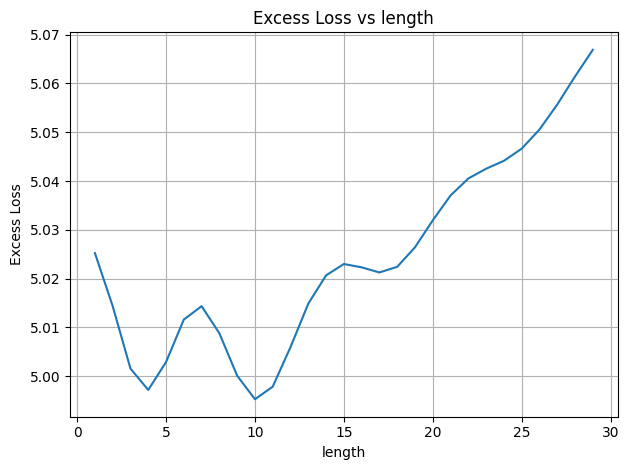

In [17]:
backend.switch_to_layout()  # cell groups can only be edited in layout mode
cell_range = backend.expand_eme_cell_group(3)
backend.run_eme()  # re-enter analysis mode so the sweep can set group spans and propagate
excess_loss, summary = taper_length_sweep(backend, cell_range=cell_range, filename="dual_transition_sin_to_si_1550nm_sweep.csv")